# Notebook 04: Deep Dive & Clinical Outcomes

**Tempus HER2 Coding Challenge**

This notebook addresses:
1. Normal vs. tumor expression comparison
2. HER2-low exploration (T-DXd eligibility)
3. Discordant case deep dive (IHC/FISH/RNA/CN contradictions)
4. Clinical outcome validation (KM curves, Cox regression)
5. Population sizing and actionability

**Inputs:** Intermediates from Notebooks 01–03
**Outputs:** Figures and summary tables

---
## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.utils import (
    load_intermediate, load_gene_cols, save_intermediate, savefig,
    setup_plotting, get_color, classify_her2_spectrum,
    COLORS, HER2_PATHWAY_GENES
)

setup_plotting()

In [2]:
# Load all intermediates
clinical = load_intermediate('01_clinical_qc')
tumor_norm = load_intermediate('01_tumor_norm')
gene_cols = load_gene_cols()
cohort_c = load_intermediate('02_multimodal_cohort')
analysis_df = load_intermediate('02_analysis_df')
predictions = load_intermediate('03_ml_predictions')
clusters = load_intermediate('02_cluster_assignments')

try:
    normal_norm = load_intermediate('01_normal_raw_filtered')
    has_normal = True
except FileNotFoundError:
    has_normal = False
    print("No normal tissue data available.")

try:
    discordant_df = load_intermediate('02_discordant_cases')
    has_discordant = True
except FileNotFoundError:
    has_discordant = False
    print("No discordant cases file available.")

try:
    equivocal_scores = load_intermediate('03_equivocal_scores')
    has_equivocal = True
except FileNotFoundError:
    has_equivocal = False

  Loaded: outputs\01_clinical_qc.parquet  (1108 rows × 148 cols)
  Loaded: outputs\01_tumor_norm.parquet  (1093 rows × 17638 cols)
  Loaded: outputs\01_gene_cols.json  (17637 genes)
  Loaded: outputs\02_multimodal_cohort.parquet  (966 rows × 17786 cols)
  Loaded: outputs\02_analysis_df.parquet  (966 rows × 17793 cols)
  Loaded: outputs\03_ml_predictions.parquet  (966 rows × 7 cols)
  Loaded: outputs\02_cluster_assignments.parquet  (1093 rows × 4 cols)
  Loaded: outputs\01_normal_raw_filtered.parquet  (112 rows × 17638 cols)
  Loaded: outputs\02_discordant_cases.parquet  (69 rows × 8 cols)
  Loaded: outputs\03_equivocal_scores.parquet  (28 rows × 4 cols)


---
## 2. Normal vs. Tumor Expression

Compare key gene expression between adjacent normal tissue and primary tumor.
Normal tissue expression provides a baseline for defining overexpression thresholds.

NORMAL vs. TUMOR EXPRESSION
Key genes available: ['ERBB2', 'GRB7', 'ESR1', 'PGR', 'MKI67', 'EGFR', 'ERBB3']
Normal samples: 112
Tumor samples: 1093

      Gene   Tumor Med   Normal Med    log2FC     p-value
------------------------------------------------------------
     ERBB2       12.78        12.24     +0.54    2.10e-14 ***
      GRB7        9.06         8.78     +0.27    1.22e-04 ***
      ESR1       12.79        11.44     +1.36    5.07e-09 ***
       PGR        9.50        10.37     -0.87    2.24e-03 *
     MKI67       10.73         7.44     +3.29    2.36e-55 ***
      EGFR        7.38        10.85     -3.47    4.11e-55 ***
     ERBB3       12.77        11.90     +0.86    3.12e-20 ***

⚠ Normal tissue sample size (n=112) — interpret with caution.
  Saved figure: fig19_normal_vs_tumor


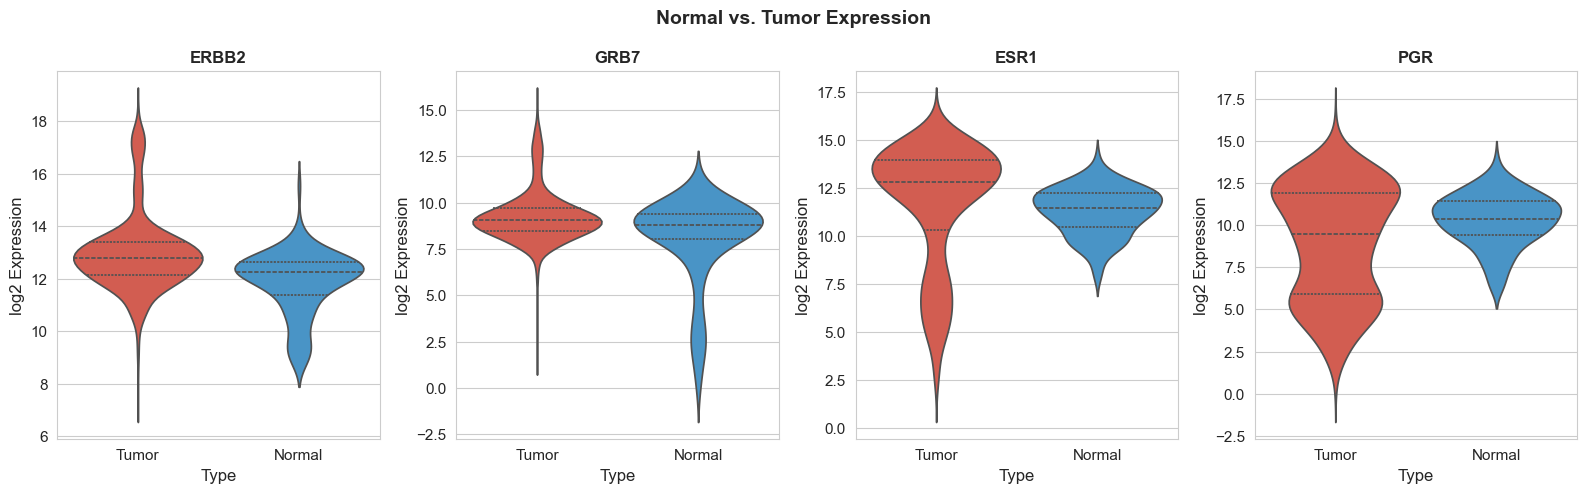


ERBB2 overexpression threshold (normal mean + 2SD): 14.27
HER2-negative patients exceeding this threshold: 3/686 (0.4%)


In [3]:
print("=" * 70)
print("NORMAL vs. TUMOR EXPRESSION")
print("=" * 70)

if has_normal:
    # Key genes to compare
    key_genes = [g for g in ['ERBB2', 'GRB7', 'ESR1', 'PGR', 'MKI67', 'EGFR', 'ERBB3']
                 if g in gene_cols and g in normal_norm.columns and g in tumor_norm.columns]
    
    print(f"Key genes available: {key_genes}")
    print(f"Normal samples: {len(normal_norm)}")
    print(f"Tumor samples: {len(tumor_norm)}")
    
    if len(key_genes) > 0:
        # Compute statistics
        comparison_data = []
        for gene in key_genes:
            tumor_vals = tumor_norm[gene].dropna()
            normal_vals = normal_norm[gene].dropna()
            
            if len(normal_vals) > 0 and len(tumor_vals) > 0:
                u_stat, p_val = stats.mannwhitneyu(tumor_vals, normal_vals, alternative='two-sided')
                log2fc = tumor_vals.median() - normal_vals.median()
                
                comparison_data.append({
                    'gene': gene,
                    'tumor_median': tumor_vals.median(),
                    'normal_median': normal_vals.median(),
                    'log2FC': log2fc,
                    'p_value': p_val,
                    'n_tumor': len(tumor_vals),
                    'n_normal': len(normal_vals),
                })
        
        comp_df = pd.DataFrame(comparison_data)
        comp_df['p_adjusted'] = comp_df['p_value'] * len(comp_df)  # Bonferroni
        
        print(f"\n{'Gene':>10s}  {'Tumor Med':>10s}  {'Normal Med':>11s}  {'log2FC':>8s}  {'p-value':>10s}")
        print("-" * 60)
        for _, row in comp_df.iterrows():
            sig = "***" if row['p_adjusted'] < 0.001 else "**" if row['p_adjusted'] < 0.01 else "*" if row['p_adjusted'] < 0.05 else ""
            print(f"  {row['gene']:>8s}  {row['tumor_median']:>10.2f}  {row['normal_median']:>11.2f}  "
                  f"{row['log2FC']:>+8.2f}  {row['p_value']:>10.2e} {sig}")
        
        print(f"\n⚠ Normal tissue sample size (n={len(normal_norm)}) — interpret with caution.")
        
        # Visualization
        n_genes_plot = len(key_genes)
        fig, axes = plt.subplots(1, min(n_genes_plot, 4), figsize=(4*min(n_genes_plot, 4), 5))
        if n_genes_plot == 1:
            axes = [axes]
        
        for ax, gene in zip(axes, key_genes[:4]):
            tumor_vals = tumor_norm[gene].dropna()
            normal_vals = normal_norm[gene].dropna()
            
            data_plot = pd.DataFrame({
                'Expression': pd.concat([tumor_vals, normal_vals]),
                'Type': ['Tumor'] * len(tumor_vals) + ['Normal'] * len(normal_vals)
            })
            
            sns.violinplot(data=data_plot, x='Type', y='Expression', ax=ax,
                          palette={'Tumor': '#e74c3c', 'Normal': '#3498db'}, inner='quartile')
            ax.set_title(gene, fontsize=12, fontweight='bold')
            ax.set_ylabel('log2 Expression')
        
        plt.suptitle('Normal vs. Tumor Expression', fontsize=14, fontweight='bold')
        plt.tight_layout()
        savefig(fig, 'fig19_normal_vs_tumor')
        plt.show()
        
        # ERBB2 overexpression threshold from normal tissue
        if 'ERBB2' in key_genes:
            erbb2_normal = normal_norm['ERBB2'].dropna()
            threshold_2sd = erbb2_normal.mean() + 2 * erbb2_normal.std()
            
            # How many HER2-negative patients exceed this threshold?
            neg_patients = cohort_c[cohort_c['her2_composite'] == 'Negative']
            if 'ERBB2' in neg_patients.columns:
                n_exceed = (neg_patients['ERBB2'] > threshold_2sd).sum()
                print(f"\nERBB2 overexpression threshold (normal mean + 2SD): {threshold_2sd:.2f}")
                print(f"HER2-negative patients exceeding this threshold: {n_exceed}/{len(neg_patients)} "
                      f"({100*n_exceed/max(len(neg_patients),1):.1f}%)")
    else:
        print("No key genes found in both tumor and normal datasets.")
else:
    print("Normal tissue data not available. Skipping comparison.")

---
## 3. HER2-Low Exploration

HER2-low (IHC 1+ or IHC 2+/FISH-) is clinically relevant for T-DXd eligibility
(DESTINY-Breast04). We characterize RNA and CN profiles across the HER2 spectrum.

In [4]:
print("=" * 70)
print("HER2-LOW EXPLORATION")
print("=" * 70)

# Apply spectrum classification
cohort_c['her2_level'] = cohort_c.apply(classify_her2_spectrum, axis=1)

print("HER2 Spectrum Distribution:")
print(cohort_c['her2_level'].value_counts(dropna=False).to_string())

HER2-LOW EXPLORATION
HER2 Spectrum Distribution:
her2_level
NaN                    371
HER2-Low               362
HER2-Positive          151
HER2-0                  60
HER2-Low (presumed)     22


  Saved figure: fig20_her2_spectrum


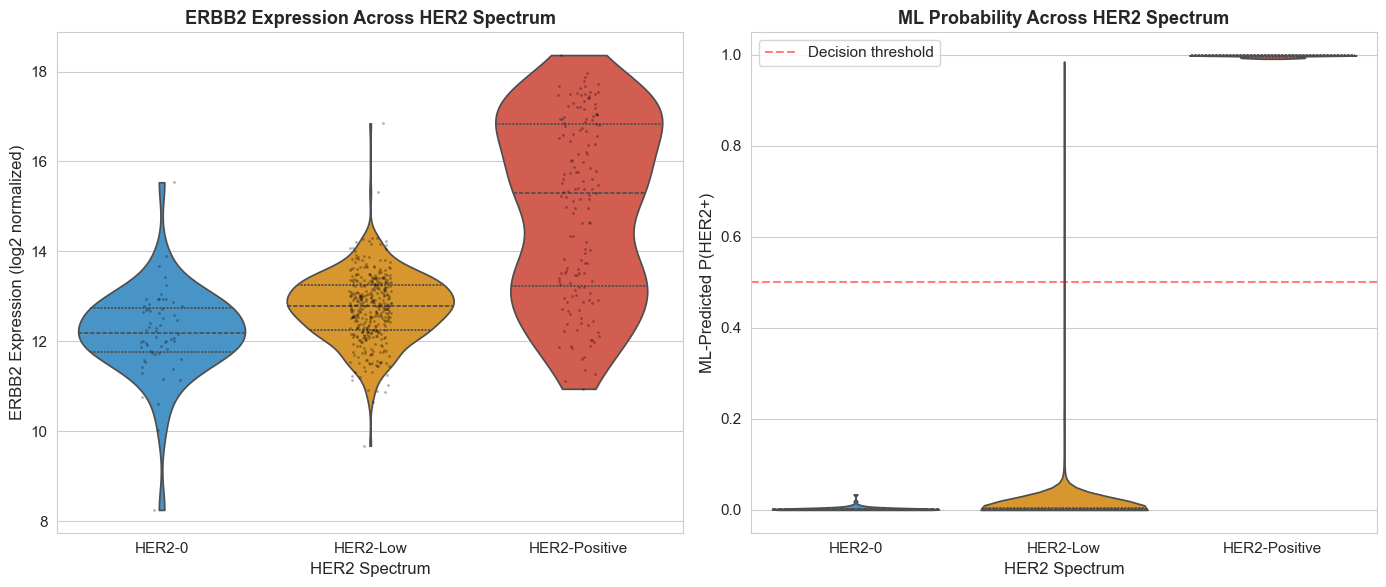


ERBB2 expression by HER2 spectrum:
  HER2-0         : n=60, median=12.19, IQR=[11.77, 12.73]
  HER2-Low       : n=384, median=12.79, IQR=[12.25, 13.26]
  HER2-Positive  : n=151, median=15.30, IQR=[13.24, 16.84]


In [5]:
# Expression across the HER2 spectrum
her2_levels = ['HER2-0', 'HER2-Low', 'HER2-Low (presumed)', 'HER2-Positive']
spectrum_data = cohort_c[cohort_c['her2_level'].isin(her2_levels)]

if len(spectrum_data) > 5 and 'ERBB2' in gene_cols and 'ERBB2' in spectrum_data.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Combine "HER2-Low" and "HER2-Low (presumed)" for cleaner visualization
    spectrum_data = spectrum_data.copy()
    spectrum_data['her2_level_clean'] = spectrum_data['her2_level'].replace(
        'HER2-Low (presumed)', 'HER2-Low')
    
    level_order = ['HER2-0', 'HER2-Low', 'HER2-Positive']
    level_colors = {'HER2-0': '#3498db', 'HER2-Low': '#f39c12', 'HER2-Positive': '#e74c3c'}
    
    # ERBB2 expression by spectrum
    sns.violinplot(data=spectrum_data, x='her2_level_clean', y='ERBB2', order=level_order,
                   palette=level_colors, inner='quartile', ax=axes[0], cut=0)
    sns.stripplot(data=spectrum_data, x='her2_level_clean', y='ERBB2', order=level_order,
                  color='black', size=2, alpha=0.3, jitter=True, ax=axes[0])
    axes[0].set_xlabel('HER2 Spectrum')
    axes[0].set_ylabel('ERBB2 Expression (log2 normalized)')
    axes[0].set_title('ERBB2 Expression Across HER2 Spectrum', fontsize=13, fontweight='bold')
    
    # ML probability by spectrum
    spectrum_with_ml = spectrum_data.merge(predictions[['pid', 'ml_prob_her2_positive']], on='pid', how='left')
    
    if 'ml_prob_her2_positive' in spectrum_with_ml.columns:
        sns.violinplot(data=spectrum_with_ml, x='her2_level_clean', y='ml_prob_her2_positive',
                       order=level_order, palette=level_colors, inner='quartile', ax=axes[1], cut=0)
        axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Decision threshold')
        axes[1].set_xlabel('HER2 Spectrum')
        axes[1].set_ylabel('ML-Predicted P(HER2+)')
        axes[1].set_title('ML Probability Across HER2 Spectrum', fontsize=13, fontweight='bold')
        axes[1].legend()
    
    plt.tight_layout()
    savefig(fig, 'fig20_her2_spectrum')
    plt.show()
    
    # Summary statistics
    print(f"\nERBB2 expression by HER2 spectrum:")
    for level in level_order:
        subset = spectrum_data[spectrum_data['her2_level_clean'] == level]
        if len(subset) > 0 and 'ERBB2' in subset.columns:
            vals = subset['ERBB2'].dropna()
            print(f"  {level:15s}: n={len(vals)}, median={vals.median():.2f}, "
                  f"IQR=[{vals.quantile(0.25):.2f}, {vals.quantile(0.75):.2f}]")
else:
    print("Insufficient data for HER2 spectrum analysis.")

---
## 4. Discordant Case Deep Dive

In [6]:
if has_discordant and len(discordant_df) > 0:
    print("=" * 70)
    print("DISCORDANT CASE DEEP DIVE")
    print("=" * 70)
    
    for dtype in discordant_df['discordance_type'].unique():
        subset = discordant_df[discordant_df['discordance_type'] == dtype]
        n_patients = subset['pid'].nunique()
        
        print(f"\n--- {dtype} (n={n_patients}) ---")
        
        # Expression summary
        expr_vals = subset['ERBB2_expr'].dropna()
        if len(expr_vals) > 0:
            print(f"  ERBB2 expression: median={expr_vals.median():.2f}, "
                  f"range=[{expr_vals.min():.2f}, {expr_vals.max():.2f}]")
        
        # GRB7 co-expression
        grb7_vals = subset['GRB7_expr'].dropna()
        if len(grb7_vals) > 0:
            all_grb7 = analysis_df.get('GRB7_expr', pd.Series()).dropna()
            grb7_pctl = (grb7_vals.median() > all_grb7).mean() * 100 if len(all_grb7) > 0 else np.nan
            print(f"  GRB7 co-expression: median={grb7_vals.median():.2f} "
                  f"(at {grb7_pctl:.0f}th percentile of cohort)")
        
        # ML predictions for these patients
        disc_pids = subset['pid'].unique()
        disc_ml = predictions[predictions['pid'].isin(disc_pids)]
        if len(disc_ml) > 0 and 'ml_prob_her2_positive' in disc_ml.columns:
            ml_probs = disc_ml['ml_prob_her2_positive'].dropna()
            n_ml_pos = (ml_probs > 0.5).sum()
            print(f"  ML prediction: {n_ml_pos}/{len(ml_probs)} classified as HER2+ by ML "
                  f"(median P = {ml_probs.median():.3f})")
        
        # Cluster membership
        disc_clusters = clusters[clusters['pid'].isin(disc_pids)]
        if 'cluster_k4' in disc_clusters.columns:
            print(f"  Cluster distribution (k=4): {disc_clusters['cluster_k4'].value_counts().to_dict()}")
        
        # Biological interpretation
        if dtype == 'IHC3+/FISH-':
            print(f"  → Possible polysomy 17. Check HER2/CEP17 ratio where available.")
            # Check ratio data
            cent17_data = analysis_df.loc[analysis_df['pid'].isin(disc_pids), 
                                          'HER2 cent17 ratio'].dropna()
            if len(cent17_data) > 0:
                print(f"  HER2/CEP17 ratio available: {len(cent17_data)} patients, "
                      f"median = {pd.to_numeric(cent17_data, errors='coerce').median():.2f}")
        
        elif dtype == 'IHC-/RNA-high':
            print(f"  → Potential missed HER2+ patients. These are the primary candidates")
            print(f"    for RNA-based reclassification and HER2-directed therapy.")
        
        elif dtype == 'IHC-low/FISH+':
            print(f"  → Amplification without overexpression. May reflect epigenetic silencing")
            print(f"    or post-translational regulation. RNA-seq captures functional state.")
else:
    print("No discordant cases to analyze.")

DISCORDANT CASE DEEP DIVE

--- IHC-/RNA-high (n=35) ---
  ERBB2 expression: median=13.89, range=[13.75, 16.85]
  GRB7 co-expression: median=9.97 (at 82th percentile of cohort)
  ML prediction: 0/35 classified as HER2+ by ML (median P = 0.005)
  Cluster distribution (k=4): {2: 16, 3: 9, 1: 8, 0: 2}
  → Potential missed HER2+ patients. These are the primary candidates
    for RNA-based reclassification and HER2-directed therapy.

--- IHC-low/FISH+ (n=3) ---
  ERBB2 expression: median=11.59, range=[11.02, 14.08]
  GRB7 co-expression: median=9.05 (at 52th percentile of cohort)
  ML prediction: 0/3 classified as HER2+ by ML (median P = 0.003)
  Cluster distribution (k=4): {0: 3}
  → Amplification without overexpression. May reflect epigenetic silencing
    or post-translational regulation. RNA-seq captures functional state.

--- IHC3+/FISH- (n=3) ---
  ERBB2 expression: median=12.68, range=[12.61, 13.57]
  GRB7 co-expression: median=9.47 (at 70th percentile of cohort)
  ML prediction: 3/3 c

---
## 5. Clinical Outcome Validation

We use survival data to ask: do our molecular classifications connect to patient 
outcomes? This validates that our findings are actionable, not just statistically 
separable.

**Caveats (stated upfront):**
1. Treatment confounding — HER2+ patients likely received trastuzumab
2. Small sample size — ~200 patients, limited events
3. TCGA is not a clinical trial — heterogeneous treatment, variable follow-up
4. Hypothesis-generating, not definitive

In [7]:
print("=" * 70)
print("CLINICAL OUTCOME ANALYSIS")
print("=" * 70)

# Prepare survival data
surv_df = cohort_c.copy()

# Parse OS
if 'Overall Survival (Months)' in surv_df.columns:
    surv_df['os_months'] = pd.to_numeric(surv_df['Overall Survival (Months)'], errors='coerce')
if 'Overall Survival Status' in surv_df.columns:
    surv_df['os_event'] = surv_df['Overall Survival Status'].apply(
        lambda x: 1 if isinstance(x, str) and 'DECEASED' in x.upper() else 0)

# Parse DFS
if 'Disease Free (Months)' in surv_df.columns:
    surv_df['dfs_months'] = pd.to_numeric(surv_df['Disease Free (Months)'], errors='coerce')
if 'Disease Free Status' in surv_df.columns:
    surv_df['dfs_event'] = surv_df['Disease Free Status'].apply(
        lambda x: 1 if isinstance(x, str) and 'Recurred' in x else 0)

# Check completeness
os_complete = surv_df[['os_months', 'os_event']].dropna()
dfs_complete = surv_df[['dfs_months', 'dfs_event']].dropna()

print(f"OS data: {len(os_complete)} patients, {os_complete['os_event'].sum()} events")
print(f"DFS data: {len(dfs_complete)} patients, {dfs_complete['dfs_event'].sum()} events")
print(f"Median OS follow-up: {os_complete['os_months'].median():.1f} months")
if len(dfs_complete) > 0:
    print(f"Median DFS follow-up: {dfs_complete['dfs_months'].median():.1f} months")

# Determine which endpoint to use
if len(dfs_complete) >= 100 and dfs_complete['dfs_event'].sum() >= 20:
    primary_endpoint = 'dfs'
    print("\n→ Using DFS as primary endpoint (preferred: more proximal to tumor biology).")
elif len(os_complete) >= 100 and os_complete['os_event'].sum() >= 20:
    primary_endpoint = 'os'
    print("\n→ Using OS as primary endpoint (DFS has insufficient data).")
else:
    primary_endpoint = None
    print("\n⚠ Insufficient events for formal survival analysis.")
    print("  Will attempt descriptive KM curves if any data is available.")

CLINICAL OUTCOME ANALYSIS
OS data: 965 patients, 138 events
DFS data: 879 patients, 102 events
Median OS follow-up: 30.2 months
Median DFS follow-up: 25.7 months

→ Using DFS as primary endpoint (preferred: more proximal to tumor biology).


In [8]:
# Kaplan-Meier analysis
try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test
    has_lifelines = True
except ImportError:
    has_lifelines = False
    print("lifelines not available. Install with: pip install lifelines")
    print("Skipping KM curves.")

  Saved figure: fig21_km_by_cluster


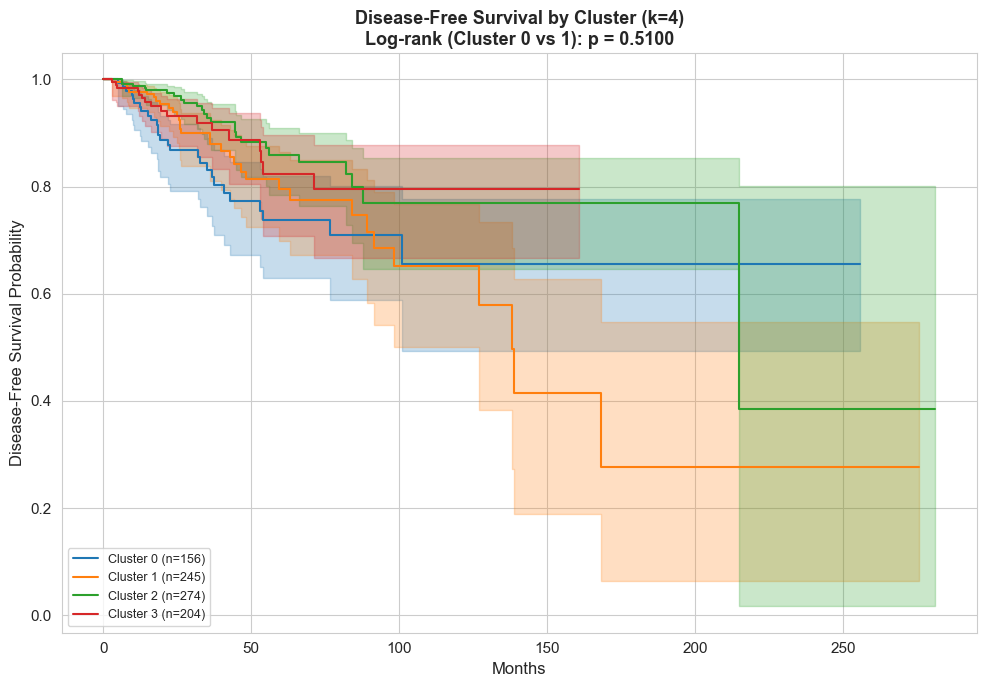

In [9]:
# 5a. KM curves by cluster membership
if has_lifelines and primary_endpoint is not None:
    # Merge survival data with clusters
    surv_clusters = surv_df.merge(clusters, on='pid', how='inner')
    
    time_col = f'{primary_endpoint}_months'
    event_col = f'{primary_endpoint}_event'
    endpoint_label = 'Disease-Free Survival' if primary_endpoint == 'dfs' else 'Overall Survival'
    
    # Use k=4 clusters
    if 'cluster_k4' in surv_clusters.columns:
        valid = surv_clusters[[time_col, event_col, 'cluster_k4']].dropna()
        
        if len(valid) > 20:
            fig, ax = plt.subplots(figsize=(10, 7))
            kmf = KaplanMeierFitter()
            
            for cluster in sorted(valid['cluster_k4'].unique()):
                mask = valid['cluster_k4'] == cluster
                n_cluster = mask.sum()
                kmf.fit(valid.loc[mask, time_col], valid.loc[mask, event_col],
                       label=f'Cluster {cluster} (n={n_cluster})')
                kmf.plot_survival_function(ax=ax, ci_show=True)
            
            # Log-rank test
            groups = [valid.loc[valid['cluster_k4'] == c, [time_col, event_col]] 
                     for c in sorted(valid['cluster_k4'].unique())]
            if len(groups) >= 2:
                # Pairwise log-rank between clusters with most/least HER2+
                result = logrank_test(
                    groups[0][time_col], groups[1][time_col],
                    groups[0][event_col], groups[1][event_col]
                )
                ax.set_title(f'{endpoint_label} by Cluster (k=4)\n'
                            f'Log-rank (Cluster 0 vs 1): p = {result.p_value:.4f}',
                            fontsize=13, fontweight='bold')
            
            ax.set_xlabel('Months')
            ax.set_ylabel(f'{endpoint_label} Probability')
            ax.legend(loc='lower left', fontsize=9)
            plt.tight_layout()
            savefig(fig, 'fig21_km_by_cluster')
            plt.show()

In [10]:
# 5b. KM curves: discordant vs concordant HER2-negative patients
if has_lifelines and primary_endpoint is not None:
    surv_ml = surv_df.merge(predictions[['pid', 'ml_prob_her2_positive']], on='pid', how='inner')
    
    time_col = f'{primary_endpoint}_months'
    event_col = f'{primary_endpoint}_event'
    
    # Among clinically HER2-negative patients
    her2_neg = surv_ml[surv_ml['her2_composite'] == 'Negative'].copy()
    
    if len(her2_neg) > 20:
        # Define molecular concordance
        # "Discordant": IHC- but ML says P(HER2+) > 0.3 (lenient threshold)
        her2_neg['molecular_status'] = np.where(
            her2_neg['ml_prob_her2_positive'] > 0.3,
            'Molecularly Discordant\n(IHC-, ML suggests HER2+)',
            'Concordant HER2-Negative'
        )
        
        valid = her2_neg[[time_col, event_col, 'molecular_status']].dropna()
        
        if valid['molecular_status'].nunique() > 1 and len(valid) > 20:
            fig, ax = plt.subplots(figsize=(10, 7))
            kmf = KaplanMeierFitter()
            
            for status in valid['molecular_status'].unique():
                mask = valid['molecular_status'] == status
                n = mask.sum()
                events = valid.loc[mask, event_col].sum()
                kmf.fit(valid.loc[mask, time_col], valid.loc[mask, event_col],
                       label=f'{status} (n={n}, events={int(events)})')
                kmf.plot_survival_function(ax=ax, ci_show=True)
            
            # Log-rank test
            groups_disc = valid.groupby('molecular_status')
            g_names = list(groups_disc.groups.keys())
            if len(g_names) == 2:
                g1 = groups_disc.get_group(g_names[0])
                g2 = groups_disc.get_group(g_names[1])
                lr_result = logrank_test(g1[time_col], g2[time_col], g1[event_col], g2[event_col])
                ax.set_title(f'{endpoint_label}: Concordant vs Discordant HER2-Negative\n'
                            f'Log-rank p = {lr_result.p_value:.4f}',
                            fontsize=13, fontweight='bold')
            
            ax.set_xlabel('Months')
            ax.set_ylabel(f'{endpoint_label} Probability')
            ax.legend(loc='lower left', fontsize=9)
            plt.tight_layout()
            savefig(fig, 'fig22_km_discordant')
            plt.show()
            
            print(f"\nDiscordant case survival analysis:")
            for status in valid['molecular_status'].unique():
                mask = valid['molecular_status'] == status
                n = mask.sum()
                events = valid.loc[mask, event_col].sum()
                median_surv = valid.loc[mask, time_col].median()
                print(f"  {status}: n={n}, events={int(events)}, median follow-up={median_surv:.1f} months")
        else:
            print("Insufficient data for discordant survival comparison.")

Insufficient data for discordant survival comparison.


In [11]:
# 5c. Cox regression (hypothesis-generating)
if has_lifelines and primary_endpoint is not None:
    try:
        from lifelines import CoxPHFitter
        
        print("=" * 70)
        print("COX REGRESSION (hypothesis-generating)")
        print("=" * 70)
        
        cox_df = surv_ml.copy()
        time_col = f'{primary_endpoint}_months'
        event_col = f'{primary_endpoint}_event'
        
        # Molecular HER2 status (binary)
        cox_df['mol_her2_pos'] = (cox_df['ml_prob_her2_positive'] > 0.5).astype(float)
        
        # Stage (simplify to numeric)
        stage_map = {'Stage I': 1, 'Stage IA': 1, 'Stage IB': 1,
                     'Stage II': 2, 'Stage IIA': 2, 'Stage IIB': 2,
                     'Stage III': 3, 'Stage IIIA': 3, 'Stage IIIB': 3, 'Stage IIIC': 3,
                     'Stage IV': 4, 'Stage X': np.nan}
        stage_col = 'Neoplasm Disease Stage American Joint Committee on Cancer Code'
        if stage_col in cox_df.columns:
            cox_df['stage_numeric'] = cox_df[stage_col].map(stage_map)
        
        # ER status (binary)
        cox_df['er_pos'] = (cox_df['ER Status By IHC'] == 'Positive').astype(float)
        
        # Model 1: Univariable
        cox_vars_uni = [time_col, event_col, 'mol_her2_pos']
        cox_data_uni = cox_df[cox_vars_uni].dropna()
        
        if len(cox_data_uni) > 30 and cox_data_uni[event_col].sum() >= 10:
            cph = CoxPHFitter()
            cph.fit(cox_data_uni, duration_col=time_col, event_col=event_col)
            
            print(f"\nModel 1 — Univariable: {primary_endpoint.upper()} ~ molecular_HER2")
            cph.print_summary()
            
            # Model 2: Multivariable
            if 'stage_numeric' in cox_df.columns:
                cox_vars_multi = [time_col, event_col, 'mol_her2_pos', 'stage_numeric', 'er_pos']
                cox_data_multi = cox_df[cox_vars_multi].dropna()
                
                if len(cox_data_multi) > 30:
                    cph_multi = CoxPHFitter()
                    cph_multi.fit(cox_data_multi, duration_col=time_col, event_col=event_col)
                    
                    print(f"\nModel 2 — Multivariable: {primary_endpoint.upper()} ~ molecular_HER2 + stage + ER")
                    cph_multi.print_summary()
                    
                    # Interpretation
                    hr = np.exp(cph_multi.params_['mol_her2_pos'])
                    p_val = cph_multi.summary.loc['mol_her2_pos', 'p']
                    print(f"\n→ Molecular HER2 HR = {hr:.2f} (p = {p_val:.4f}) after adjustment")
                    if p_val < 0.05:
                        print("  HR remains significant after adjustment → independent prognostic information")
                    else:
                        print("  HR not significant after adjustment → molecular HER2 may be proxy for stage/ER")
                    print("  ⚠ Hypothesis-generating only. Confounded by treatment (trastuzumab for HER2+).")
        else:
            print(f"Insufficient data for Cox regression (n={len(cox_data_uni)}, events={cox_data_uni[event_col].sum()}).")
    
    except ImportError:
        print("lifelines.CoxPHFitter not available. Skipping Cox regression.")

COX REGRESSION (hypothesis-generating)

Model 1 — Univariable: DFS ~ molecular_HER2


<lifelines.CoxPHFitter: fitted with 885 total observations, 783 right-censored observations>
             duration col = 'dfs_months'
                event col = 'dfs_event'
      baseline estimation = breslow
   number of observations = 885
number of events observed = 102
   partial log-likelihood = -587.37
         time fit was run = 2026-04-04 11:54:33 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
mol_her2_pos -0.27      0.76      0.30           -0.85            0.31                0.43                1.36

              cmp to     z    p  -log2(p)
covariate                                
mol_her2_pos    0.00 -0.91 0.36      1.47
---
Concordance = 0.51
Partial AIC = 1176.74
log-likelihood ratio test = 0.89 on 1 df
-log2(p) of ll-ratio test = 1.54


Model 2 — Multivariable: DFS ~ molecular_HER2 + stage + ER


<lifelines.CoxPHFitter: fitted with 868 total observations, 772 right-censored observations>
             duration col = 'dfs_months'
                event col = 'dfs_event'
      baseline estimation = breslow
   number of observations = 868
number of events observed = 96
   partial log-likelihood = -531.14
         time fit was run = 2026-04-04 11:54:34 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
mol_her2_pos  -0.49      0.61      0.31           -1.09            0.12                0.33                1.13
stage_numeric  0.85      2.33      0.15            0.55            1.14                1.74                3.14
er_pos        -0.66      0.52      0.21           -1.08           -0.25                0.34                0.78

               cmp to     z      p  -log2(p)
covariate                                   
mol_her2_pos     0.00 -1.57   0.12      3.10
stage_numeric    0.00  5.61 <0.005     25.59
er_pos           0.00 -3.12 <0.005      9.12
---
Concordance = 0.69
Partial AIC = 1068.28
log-likelihood ratio test = 39.47 on 3 df
-log2(p) of ll-ratio test = 26.11


→ Molecular HER2 HR = 0.61 (p = 0.1163) after adjustment
  HR not significant after adjustment → molecular HER2 may be proxy for stage/ER
  ⚠ Hypothesis-generating only. Confounded by treatment (trastuzumab for HER2+).


---
## 6. Population Sizing and Actionability

For each identified patient subgroup, we quantify prevalence and extrapolate to 
US breast cancer incidence (~310,000 new cases/year) to assess clinical impact.

In [12]:
print("=" * 70)
print("POPULATION SIZING: PATIENT IDENTIFICATION OPPORTUNITIES")
print("=" * 70)

us_annual_incidence = 310000  # Approximate US breast cancer cases/year
her2_pos_rate = 0.18  # ~18% of breast cancers are HER2+

sizing_data = []

# 1. Clinically HER2-negative but molecularly HER2+
if 'ml_prob_her2_positive' in predictions.columns:
    neg_patients = predictions[predictions['her2_composite'] == 'Negative']
    n_mol_pos = (neg_patients['ml_prob_her2_positive'] > 0.5).sum()
    pct = 100 * n_mol_pos / max(len(neg_patients), 1)
    
    # Extrapolation: ~82% of breast cancers are HER2-negative
    n_extrapolated = int(us_annual_incidence * (1 - her2_pos_rate) * (pct / 100))
    
    sizing_data.append({
        'group': 'Clinically HER2- but molecularly HER2+',
        'n': n_mol_pos,
        'denominator': len(neg_patients),
        'pct': pct,
        'extrapolated_us_annual': n_extrapolated,
    })
    print(f"\n1. Clinically HER2-negative but molecularly HER2-enriched:")
    print(f"   {n_mol_pos}/{len(neg_patients)} ({pct:.1f}%)")
    print(f"   Extrapolation: ~{n_extrapolated:,} patients/year in the US")
    print(f"   → Potential candidates for HER2-directed therapy currently missed by IHC.")

# 2. Equivocal resolved by RNA
if has_equivocal and len(equivocal_scores) > 0:
    best_prob_col = [c for c in equivocal_scores.columns if c.startswith('prob_')]
    if best_prob_col:
        probs = equivocal_scores[best_prob_col[0]]
        n_resolved_pos = (probs > 0.7).sum()
        n_resolved_neg = (probs < 0.3).sum()
        n_ambiguous = len(probs) - n_resolved_pos - n_resolved_neg
        
        sizing_data.append({
            'group': 'Equivocal → likely Positive (by RNA)',
            'n': n_resolved_pos,
            'denominator': len(probs),
            'pct': 100 * n_resolved_pos / max(len(probs), 1),
        })
        sizing_data.append({
            'group': 'Equivocal → likely Negative (by RNA)',
            'n': n_resolved_neg,
            'denominator': len(probs),
            'pct': 100 * n_resolved_neg / max(len(probs), 1),
        })
        
        print(f"\n2. Equivocal IHC cases resolved by RNA-based ML:")
        print(f"   Likely Positive (P > 0.7): {n_resolved_pos}/{len(probs)}")
        print(f"   Likely Negative (P < 0.3): {n_resolved_neg}/{len(probs)}")
        print(f"   Still ambiguous:           {n_ambiguous}/{len(probs)}")
        print(f"   → RNA-seq can reduce time-to-treatment-decision for equivocal cases.")

# 3. HER2-low population
if 'her2_level' in cohort_c.columns:
    her2_low = cohort_c[cohort_c['her2_level'].isin(['HER2-Low', 'HER2-Low (presumed)'])]
    pct_low = 100 * len(her2_low) / max(len(cohort_c), 1)
    n_low_extrapolated = int(us_annual_incidence * (pct_low / 100))
    
    sizing_data.append({
        'group': 'HER2-Low (T-DXd eligible)',
        'n': len(her2_low),
        'denominator': len(cohort_c),
        'pct': pct_low,
        'extrapolated_us_annual': n_low_extrapolated,
    })
    print(f"\n3. HER2-Low population (potential T-DXd candidates):")
    print(f"   {len(her2_low)}/{len(cohort_c)} ({pct_low:.1f}%)")
    print(f"   Extrapolation: ~{n_low_extrapolated:,} patients/year in the US")

# 4. IHC 3+/FISH- (polysomy 17 suspects)
if has_discordant:
    polysomy = discordant_df[discordant_df['discordance_type'] == 'IHC3+/FISH-']
    if len(polysomy) > 0:
        her2_pos_total = (cohort_c['her2_composite'] == 'Positive').sum()
        pct_poly = 100 * polysomy['pid'].nunique() / max(her2_pos_total, 1)
        
        sizing_data.append({
            'group': 'IHC 3+/FISH- (possible polysomy 17)',
            'n': polysomy['pid'].nunique(),
            'denominator': her2_pos_total,
            'pct': pct_poly,
        })
        print(f"\n4. IHC 3+/FISH- (possible polysomy 17):")
        print(f"   {polysomy['pid'].nunique()}/{her2_pos_total} of HER2+ patients ({pct_poly:.1f}%)")
        print(f"   → RNA-seq could prevent unnecessary HER2-directed therapy.")

print(f"\n{'=' * 70}")
print("CAVEATS")
print("=" * 70)
print("- TCGA is not population-representative (academic centers, specific demographics).")
print("- Prevalence estimates are illustrative, not definitive.")
print("- Extrapolations assume TCGA rates generalize to the US population.")
print("- Treatment decisions require prospective validation, not retrospective analysis.")

POPULATION SIZING: PATIENT IDENTIFICATION OPPORTUNITIES

1. Clinically HER2-negative but molecularly HER2-enriched:
   0/686 (0.0%)
   Extrapolation: ~0 patients/year in the US
   → Potential candidates for HER2-directed therapy currently missed by IHC.

2. Equivocal IHC cases resolved by RNA-based ML:
   Likely Positive (P > 0.7): 6/28
   Likely Negative (P < 0.3): 20/28
   Still ambiguous:           2/28
   → RNA-seq can reduce time-to-treatment-decision for equivocal cases.

3. HER2-Low population (potential T-DXd candidates):
   384/966 (39.8%)
   Extrapolation: ~123,229 patients/year in the US

4. IHC 3+/FISH- (possible polysomy 17):
   3/151 of HER2+ patients (2.0%)
   → RNA-seq could prevent unnecessary HER2-directed therapy.

CAVEATS
- TCGA is not population-representative (academic centers, specific demographics).
- Prevalence estimates are illustrative, not definitive.
- Extrapolations assume TCGA rates generalize to the US population.
- Treatment decisions require prospectiv

In [13]:
# Multi-modal corroboration for molecularly discordant cases
if 'ml_prob_her2_positive' in predictions.columns and has_discordant:
    print("=" * 70)
    print("MULTI-MODAL CORROBORATION: Clinically HER2- / Molecularly HER2+")
    print("=" * 70)
    
    neg_mol_pos = predictions[
        (predictions['her2_composite'] == 'Negative') & 
        (predictions['ml_prob_her2_positive'] > 0.5)
    ]
    
    if len(neg_mol_pos) > 0:
        # Check multiple lines of evidence
        corroboration = neg_mol_pos.merge(cohort_c[['pid', 'erbb2_copy_number'] + 
                                                    [g for g in ['ERBB2', 'GRB7'] if g in cohort_c.columns]], 
                                           on='pid', how='left')
        
        print(f"\nMolecularly discordant patients (IHC-, ML HER2+): {len(corroboration)}")
        
        evidence_count = []
        for _, row in corroboration.iterrows():
            n_evidence = 0
            if row.get('ERBB2', 0) > neg_expr.quantile(0.95) if len(neg_expr) > 0 else False:
                n_evidence += 1
            if 'GRB7' in row and row.get('GRB7', 0) > 0:
                # Check if GRB7 is elevated
                all_grb7_median = cohort_c.get('GRB7', pd.Series()).median()
                if row.get('GRB7', 0) > all_grb7_median:
                    n_evidence += 1
            if row.get('erbb2_copy_number', 0) >= 1:
                n_evidence += 1
            n_evidence += 1  # ML prediction counts as evidence
            evidence_count.append(n_evidence)
        
        corroboration['n_evidence'] = evidence_count
        
        print(f"\nConfidence tiers (lines of molecular evidence):")
        for tier in sorted(corroboration['n_evidence'].unique()):
            n = (corroboration['n_evidence'] == tier).sum()
            print(f"  {tier} lines of evidence: {n} patients")
        
        high_confidence = (corroboration['n_evidence'] >= 3).sum()
        print(f"\nHigh-confidence reclassification candidates (≥3 evidence lines): {high_confidence}")

MULTI-MODAL CORROBORATION: Clinically HER2- / Molecularly HER2+


---
## 7. Clinical Utility Framing

RNA-seq-based HER2 classification could serve as:

1. **Reflex test for IHC-equivocal cases** — reducing time to treatment decision 
   by resolving ambiguous IHC results without waiting for FISH.

2. **Complementary screen** — identifying HER2-directed therapy candidates missed 
   by IHC alone, particularly in the IHC 0/1+ population where FISH is not 
   reflexively ordered.

3. **HER2-low stratification** — distinguishing HER2-0 from HER2-low for T-DXd 
   eligibility, a distinction that is poorly reproducible by IHC alone.

The population sizing shows this is not a niche finding: if even 5% of HER2-negative 
patients are molecularly HER2-enriched, that represents ~12,000–15,000 patients/year 
in the US who might benefit from HER2-targeted agents but are currently not identified.
This aligns directly with Tempus's mission of molecular-guided therapy selection.

---
## Summary

**Normal vs. Tumor:** Key genes show expected expression differences. ERBB2 
overexpression threshold derived from normal tissue identifies additional patients 
beyond IHC categorization.

**HER2-Low:** RNA expression shows a gradient across the HER2-0/Low/Positive 
spectrum, supporting molecular refinement of the IHC-based categories. ML predictions 
mirror this gradient.

**Discordant Cases:** Multiple discordance patterns identified with distinct biological 
mechanisms. GRB7 co-expression and multi-modal corroboration distinguish true HER2 
biology from noise.

**Clinical Outcomes (hypothesis-generating):** Cluster membership and molecular 
discordance may associate with differential survival, pending sufficient events.

**Population Sizing:** Molecularly reclassified patients represent a clinically 
meaningful population (~thousands/year US), supporting the development of RNA-based 
HER2 testing as a complement to IHC/FISH.